<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_elliptic_localized_feature_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB--Ritz Poisson problem with a localized feature

The manufactured reference
$$u_*=(1-x^2)(1-y^2)\exp[-80((x-0.7)^2+(y+0.3)^2)]$$
has a narrow off-center peak and exact homogeneous boundary data. Automatic differentiation constructs $f=-\Delta u_*$.

In [1]:
# Repository setup for a fresh Colab runtime.
import os, subprocess
from pathlib import Path
if Path('DTB_elliptic_utils.py').exists(): ROOT=Path.cwd()
else:
    ROOT=Path('/content/dtb-colab-experiments')
    if not ROOT.exists(): subprocess.run(['git','clone','-b','elliptic-pde','https://github.com/sun-mengwei/dtb-colab-experiments.git',str(ROOT)],check=True)
    os.chdir(ROOT)
print('repository:',ROOT)

repository: /content/dtb-colab-experiments


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from DTB_elliptic_utils import (MLP, armijo_update, direct_ritz_energy, envelope_gradient, expand_direction, flatten_parameters, make_box_trial, manufactured_forcing, matrix_ritz_energy, predict_tangent, relative_l2_error, sample_box, select_parameter_indices, solve_tangent_ritz, summarize_history)

torch.set_default_dtype(torch.float64); torch.manual_seed(3)
DIM, VOLUME = 2, 4.0
N_TRAIN, N_VALID = 5000, 4096
OUTER_STEPS, TANGENT_DIM = 40, 32
RIDGE_RELATIVE, INITIAL_STEP = 1e-4, 1.0
model=MLP(DIM,width=24,depth=2); theta,spec=flatten_parameters(model)
trial=make_box_trial(model,spec); indices=select_parameter_indices(theta.numel(),TANGENT_DIM,31)
x_train,x_valid=sample_box(N_TRAIN,DIM,32),sample_box(N_VALID,DIM,33)

In [3]:
import sympy, torch

print("SymPy location:", sympy.__file__)
print("SymPy version:", sympy.__version__)
print("PyTorch version:", torch.__version__)
print("Has printing:", hasattr(sympy, "printing"))

%pip install --no-cache-dir --force-reinstall "sympy==1.14.0"

SymPy location: /usr/local/lib/python3.13/dist-packages/sympy/__init__.py
SymPy version: 1.14.0
PyTorch version: 2.11.0+cpu
Has printing: True
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 99.5 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0


In [3]:
# Manufactured reference and forcing.
def exact(x):
    rho=torch.prod(1-x.square(),dim=-1)
    radius=(x[...,0]-0.7).square()+(x[...,1]+0.3).square()
    return rho*torch.exp(-80.0*radius)
f_train=manufactured_forcing(exact,x_train)
axis=torch.linspace(-1,1,91); xx,yy=torch.meshgrid(axis,axis,indexing='ij')
grid=torch.stack((xx.flatten(),yy.flatten()),dim=1)

## Runner and diagnostic snapshots

The plotted $F(\theta)$ is the unregularized empirical Ritz energy; the small ridge only stabilizes the inner linear solve.

In [4]:
history,snapshots=[],{}; snapshot_steps={0,OUTER_STEPS//2,OUTER_STEPS}
for step in range(OUTER_STEPS+1):
    solution,stiffness,load=solve_tangent_ritz(trial,theta,indices,x_train,f_train,VOLUME,ridge_relative=RIDGE_RELATIVE)
    direction=expand_direction(solution.alpha,indices,theta.numel())
    history.append(dict(
        step=step,F_theta=float(matrix_ritz_energy(stiffness,load,solution.alpha)),
        relative_l2=relative_l2_error(trial,theta,direction,x_valid,exact),
        inner_residual=solution.relative_residual,alpha_norm=float(torch.linalg.norm(solution.alpha))))
    if step in snapshot_steps:
        snapshots[step]=predict_tangent(trial,theta,direction,grid).detach().reshape(91,91).numpy()
    if step==OUTER_STEPS: break
    gradient=envelope_gradient(trial,theta,direction,x_train,f_train,VOLUME)
    fixed=lambda th: direct_ritz_energy(trial,th,direction.detach(),x_train,f_train,VOLUME)
    theta,_=armijo_update(fixed,theta,gradient,initial_step=INITIAL_STEP)
summarize_history([history[0],history[len(history)//2],history[-1]])

step=  0  F(theta)=-1.275e-02  rel-L2=8.810e-01  inner-res=9.2e-15  ||alpha||=1.59e+01
step= 20  F(theta)=-1.294e-02  rel-L2=8.799e-01  inner-res=7.0e-15  ||alpha||=1.60e+01
step= 40  F(theta)=-1.321e-02  rel-L2=8.783e-01  inner-res=9.5e-15  ||alpha||=1.63e+01


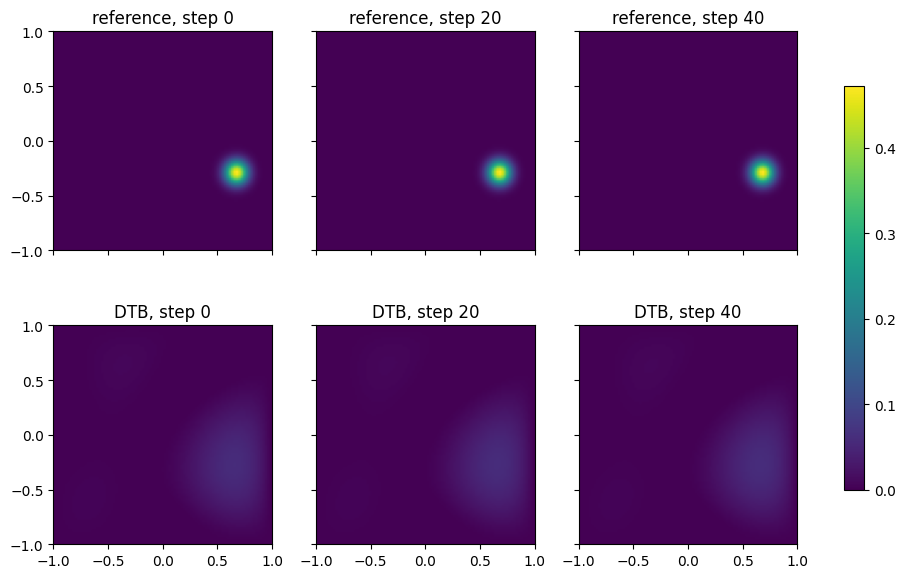

In [5]:
# The reference is repeated across columns because the elliptic target is stationary.
reference=exact(grid).reshape(91,91).numpy(); limit=float(np.max(np.abs(reference)))
fig,axes=plt.subplots(2,len(snapshots),figsize=(12,7),sharex=True,sharey=True)
for column,(step,field) in enumerate(snapshots.items()):
    for row,(values,label) in enumerate([(reference,'reference'),(field,'DTB')]):
        image=axes[row,column].imshow(values.T,origin='lower',extent=(-1,1,-1,1),cmap='viridis',vmin=0,vmax=limit)
        axes[row,column].set_title(f'{label}, step {step}')
fig.colorbar(image,ax=axes,shrink=.75); plt.show()

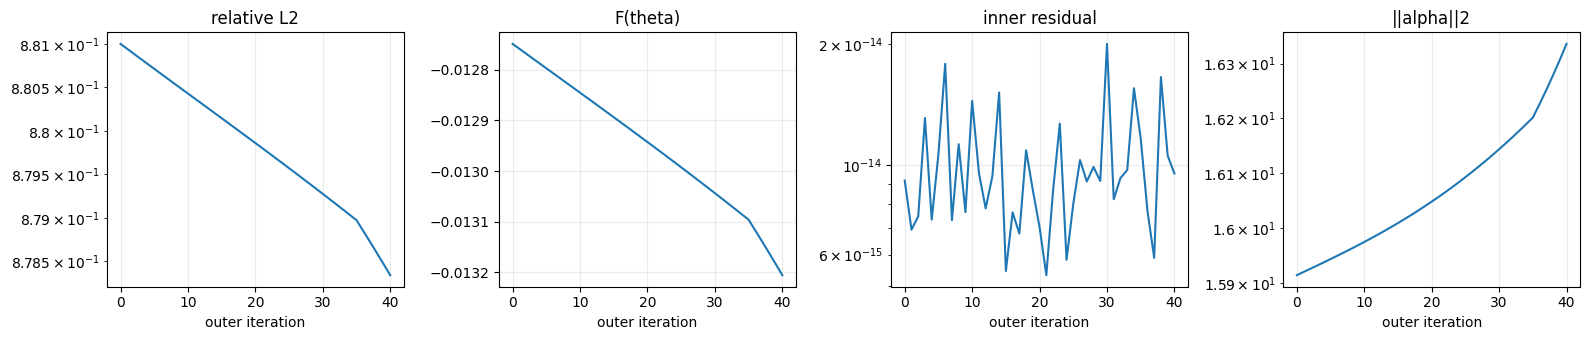

In [6]:
# Only L2 error, F(theta), inner residual, and coefficient norm.
fig,axes=plt.subplots(1,4,figsize=(16,3.5)); steps=[r['step'] for r in history]
series=[('relative_l2','relative L2',True),('F_theta','F(theta)',False),('inner_residual','inner residual',True),('alpha_norm','||alpha||2',True)]
for ax,(key,title,logy) in zip(axes,series):
    ax.plot(steps,[r[key] for r in history]); ax.set(xlabel='outer iteration',title=title); ax.grid(alpha=.25)
    if logy: ax.set_yscale('log')
plt.tight_layout(); plt.show()